In [36]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split

In [74]:
df = pd.DataFrame({
    'source': ['A', 'A', 'B', 'B'],
    'target': ['B', 'C', 'C', 'D']
})
print(df)

  source target
0      A      B
1      A      C
2      B      C
3      B      D


In [75]:
# 2) Build a directed graph from the DataFrame
G = nx.from_pandas_edgelist(df, source='source', target='target', create_using=nx.DiGraph())

In [76]:
# 3) (Optional) Add nodes explicitly if you have isolated nodes:
# G.add_node('E')  # example

In [77]:
# 4) Inspect edges and nodes
print("Nodes:", list(G.nodes()))
print("Edges:", list(G.edges()))

Nodes: ['A', 'B', 'C', 'D']
Edges: [('A', 'B'), ('A', 'C'), ('B', 'C'), ('B', 'D')]


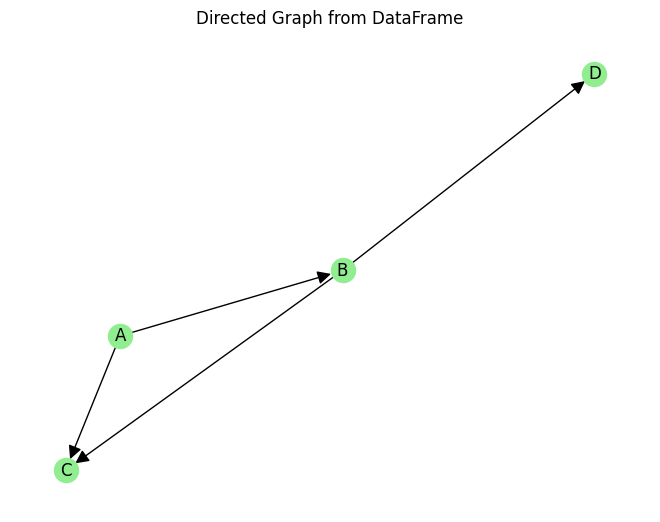

In [78]:
# plot a directed graph
pos = nx.spring_layout(G, seed=1)
nx.draw(G, pos, with_labels=True, node_color='lightgreen', arrows=True, arrowsize=20)
plt.title("Directed Graph from DataFrame")
plt.show()

In [84]:
node_to_idx = {'A':0, 'B':1, 'C':2, 'D':3}
print(node_to_idx)

{'A': 0, 'B': 1, 'C': 2, 'D': 3}


In [85]:
# Turn node notation into index
edge_list = []                     # 先準備一個空列表

for u, v in G.edges():             # 每次拿一條邊，例如 ('A','B')
    new_u = node_to_idx[u]         # 'A' → 0
    new_v = node_to_idx[v]         # 'B' → 1
    edge_list.append( (new_u, new_v) )   # 放進去 → (0, 1)

print(edge_list)

[(0, 1), (0, 2), (1, 2), (1, 3)]


In [86]:
# Another method to turn node notation into index
edge_list_try = [(node_to_idx[u], node_to_idx[v]) for u,v in G.edges()] # same as cell 85, another format

print(edge_list_try)

[(0, 1), (0, 2), (1, 2), (1, 3)]


In [142]:
pr = nx.pagerank(G, alpha=0.85)
pr_tensor = torch.tensor([pr.get(n, 0.0) for n in nodes], dtype=torch.float)

In [145]:
import torch

x = torch.tensor([10, 20, 30])   # shape: (3,)
print(x)
print(x.shape)                   # torch.Size([3])

tensor([10, 20, 30])
torch.Size([3])


In [146]:
y = x.unsqueeze(2)               # insert new dim at index 1
print(y.shape)                   # torch.Size([3, 1])
print(y)

IndexError: Dimension out of range (expected to be in range of [-2, 1], but got 2)